创建人工数据集并存储在csv文件中

In [1]:
import os
import pandas as pd
os.makedirs(os.path.join('..','data'), exist_ok=True)  # data目录存在也不会报错
data_file = os.path.join('..','data','house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n') # 列名
    f.write('NA,Pave,127500\n') # 每行表示一个数据样本
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

data = pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


处理缺失值

考虑插值法，通过位置索引iloc，把data分成inputs和outputs，其中前者为data的前两列，后者为data的第最后一列，对于inputs中缺少的数值，用同一列中的均值去代替。这里也可以使用loc（知道列的名字，按照名称选择）

In [ ]:
inputs, outputs = data.iloc[:, 0:2], data.iloc[:, 2]  # 这里用的是位置索引，只知道列的位置，不知道列的名字
inputs = inputs.fillna(inputs.mean())  # 这个地方对于pandas的新版本，不会报错，只会填充数值的列
print(inputs)

TypeError: can only concatenate str (not "int") to str

对于inputs中的NaN值，视NaN值为一个类别，对于Alley类型只接受两种类型的值，即Pave和NA，pandas会自动转换为两列"Alley_Pave"和"Alley_nan"

In [ ]:
inputs = pd.get_dummies(inputs, dummy_na=True)  # dummy是虚拟变量，把一种类别型数据转换为数值型数据
# dummy_na=True表示把NaN值也转换为一个类别，即"Alley_nan"
print(inputs)

   NumRooms  Alley_Pave  Alley_nan
0       NaN        True      False
1       2.0       False       True
2       4.0       False       True
3       NaN       False       True


转换为张量的格式

In [4]:
import torch
x = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(outputs.to_numpy(dtype=float))
x, y

c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(tensor([[nan, 1., 0.],
         [2., 0., 1.],
         [4., 0., 1.],
         [nan, 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

# 自动微分

假设想对函数 $ y = 2 x^{T}x $ 关于列向量求导

In [2]:
import torch
x = torch.arange(4.0)

c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


在计算y关于x的梯度之前，需要一个地方去存储梯度（但是不会在对每一个参数求导的时候分配新的内存）

In [3]:
x.requires_grad_(True)  # 追踪张量x的梯度信息
x.grad  # grad是张量x的一个属性，在调用backward()方法前，值为None

先计算y，再调用反向传播获取梯度

In [4]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [ ]:
y.backward()  # 在调用backward()方法后，x.grad的值为2x
x.grad


tensor([ 0.,  4.,  8., 12.])

在默认的情况下，torch会累积梯度，需要在计算完毕之后清除之前的值

In [6]:
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

## 非标量变量的反向传播

即y不再是标量，而是向量的时候

调用向量的反向计算的时候，通常会试图计算一批训练样本中每个组成部分的损失函数的导数

对于非标量调用backward()方法之前，需要先传入一个gradient参数，指定微分函数关于self的梯度（*因为标量被自动指定了gradient为1*）

In [ ]:
x.grad.zero_()

y = x * x

y.sum().backward()  # 求和得到一个标量，然后从这个标量开始反向传播
x.grad

tensor([0., 2., 4., 6.])

## 分离计算

$ y = f(x), z = g(y,x) $ ,想计算$ \frac{\partial z}{\partial x} $，由于一些原因，要把y视为一个常数并且只考虑到x在y被计算后发挥的作用；
可以通过分离y返回一个新的变量u，u和y有相同的值，但是会丢弃如何计算图中如何计算y的任何信息（即梯度不会向后流经u到x）

In [ ]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x
z.sum().backward()  # 这里计算的是y = u * x 关于x的偏导

x.grad == u

tensor([True, True, True, True])

In [10]:
x.grad.zero_()
y.sum().backward() # 再次调用反向传播

x.grad == 2 * x

tensor([True, True, True, True])

python控制流的梯度计算

In [ ]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
        
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b

    return c

a = torch.randn(size=(), requires_grad=True)  # 生成的张量的形状是一个空元组，表示这是一个标量，生成的是一个可求导的标量随机变量
d = f(a)
d.backward()

a.grad == d / a   # f(x) = k * x


tensor(True)

## 概率

抽样（sampling）， 分布（distribution）， 多项分布（multinomial distribution）。下面给出一个掷骰子的模拟程序：

multinomial.Multinomial(item1, item2)  # (试验总次数， 各个结果的概率分布) 

In [ ]:
import torch
from torch.distributions import multinomial

fair_probs = torch.ones([6]) / 6 # 创建长度为6的全1向量
multinomial.Multinomial(1, fair_probs).sample() # 从fair_probs中采样1个样本

tensor([0., 0., 1., 0., 0., 0.])

In [ ]:
multinomial.Multinomial(10, fair_probs).sample()  # 采样十个样本

tensor([0., 2., 4., 1., 1., 2.])

查看概率如何随着时间的推移收敛到真实概率

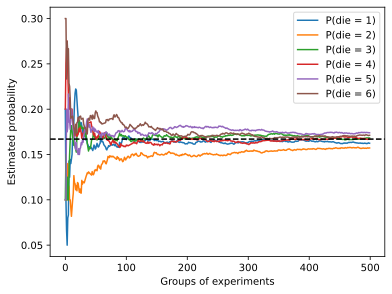

In [ ]:
from d2l import torch as d2l
counts = multinomial.Multinomial(10, fair_probs).sample((500,))  # 500次独立采样，每次采样10个，最后生成（500， 6）
cum_counts = counts.cumsum(dim=0)  # 进行累加求和，沿着dim为0的方向(每一列累加求和)
estimates = cum_counts / cum_counts.sum(dim=1, keepdim=True)  # 进行归一化处理

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(), label = f"P(die = {i+1})")

d2l.plt.axhline(y=0.167, color='black', linestyle='dashed' )  # 在图表中绘制一条水平虚线，基本收敛于1/6虚线处
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend()